In [1]:
from sklearn.metrics import mutual_info_score, adjusted_mutual_info_score, normalized_mutual_info_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics.pairwise import euclidean_distances
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

## Dataset

https://www.carroya.com/motos

## Preprocesamiento

In [2]:
datos = pd.read_csv("motos.csv")
datos


,titulo,precio,kilometros,anio
0,BMW F 800,47500000,79306,2013
1,Honda Dio,47500000,74496,2022
2,Yamaha XTZ,47000000,72699,2017
3,Honda Dio,47000000,72128,2024
4,Honda XR,46000000,71692,2024
...,...,...,...,...
1929,Kymco Fly,1900000,0,2013
1930,Honda XL,1700000,0,1982
1931,Yamaha Yzf,1500000,0,2011
1932,Harley Davidson Softail,1300000,0,1997


In [3]:
X = datos.drop('titulo', axis=1)

scale = MinMaxScaler()
scale = StandardScaler()

X = scale.fit_transform(X)
pd.DataFrame(X).describe()

pca = PCA(n_components=2).fit(X)
X_pca = pca.transform(X)

In [4]:
import pandas as pd

# Crear un DataFrame con los datos transformados por PCA
df_pca = pd.DataFrame(X_pca, columns=['Componente 1', 'Componente 2'])

# Mostrar el DataFrame
print(df_pca)


      Componente 1  Componente 2
0         9.258301     -2.389136
1         9.043281     -0.288438
2         8.750614     -1.412618
3         8.846419      0.192933
4         8.727669      0.202711
...            ...           ...
1929     -1.087454     -1.412270
1930     -1.738068     -8.498795
1931     -1.161392     -1.867188
1932     -1.464274     -5.066909
1933     -1.136997     -1.408740

[1934 rows x 2 columns]


In [5]:
X_pca

array([[ 9.25830128, -2.38913552],
       [ 9.04328143, -0.28843808],
       [ 8.75061391, -1.41261806],
       ...,
       [-1.16139238, -1.86718795],
       [-1.46427436, -5.06690899],
       [-1.13699712, -1.40874026]], shape=(1934, 2))

# DBScan

Parametros `eps` y `min_samples`.

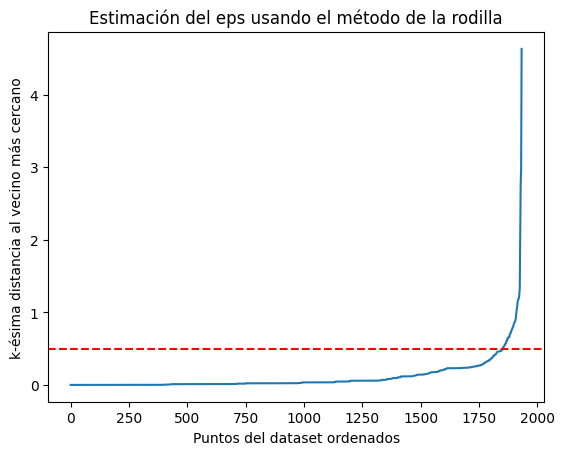

In [6]:
N = 7
nbrs = NearestNeighbors(n_neighbors=N).fit(X)
distances, indices = nbrs.kneighbors(X)

distances = np.sort(distances, axis=0)
distances = distances[:,N-1]
plt.plot(distances)
plt.axhline(y=0.50, color='r', linestyle='--') #Ajuste el valor para y
plt.title('Estimación del eps usando el método de la rodilla')
plt.xlabel('Puntos del dataset ordenados')
plt.ylabel('k-ésima distancia al vecino más cercano');

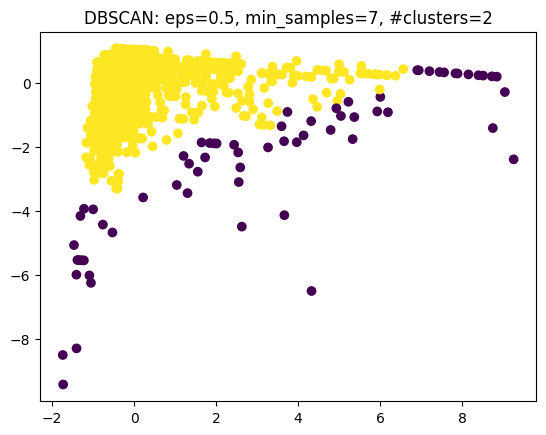

In [7]:
eps = 0.5
min_samples = 7

dbscan = DBSCAN(eps=eps, min_samples=min_samples).fit(X)
dbscan_labels = dbscan.labels_

plt.scatter(X_pca[:,0], X_pca[:,1], c=dbscan_labels)
plt.title(f"DBSCAN: eps={eps}, min_samples={min_samples}, #clusters={len(np.unique(dbscan.labels_))}")
plt.show()


#Habría que seguir explorando los parámetros, en este caso solo identificamos un cluster (+ ruido)

In [8]:
np.unique(dbscan.labels_)

array([-1,  0])

# Evaluación

## Matriz de similitud (proximidad)


In [9]:
def sim_matrix(features, labels):
    useful_labels = labels >= 0

    # primero ordenamos los datos en base al cluster que pertencen
    indices = np.argsort(labels[useful_labels])
    sorted_features = features[useful_labels][indices]

    # calculamos las distancias entre todos los puntos
    d = euclidean_distances(sorted_features, sorted_features)
    return d

def plot(data, labels):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20,5))
    ax1.scatter(data[:,0], data[:,1], c=labels)

    dist = sim_matrix(data, labels)
    im = ax2.imshow(dist, cmap="jet")
    fig.colorbar(im, ax=ax2)

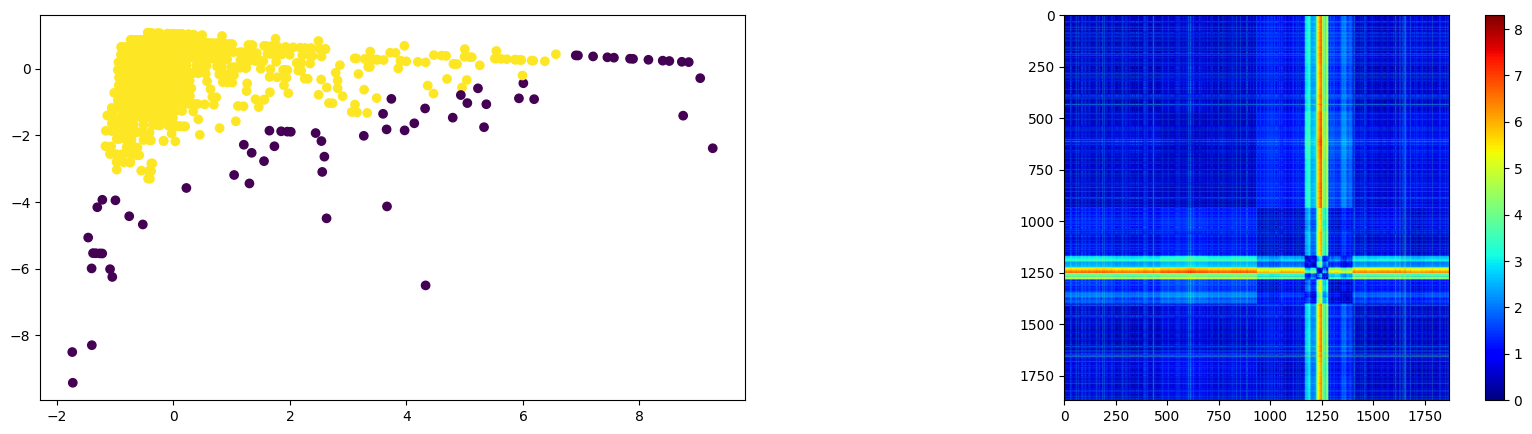

In [10]:
plot(X_pca, dbscan_labels) #solo identificamos 1 cluster
plt.show()